In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os

# Create a data directory to keep the Colab environment clean
os.makedirs('tcga_data', exist_ok=True)

print("Downloading TCGA BRCA Gene Expression Data (This may take a few minutes)...")
expr_url = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FHiSeqV2.gz"
expr_file = "tcga_data/TCGA_BRCA_expr.gz"
if not os.path.exists(expr_file):
    urllib.request.urlretrieve(expr_url, expr_file)
print("Expression data downloaded!")

print("Downloading TCGA BRCA Clinical Data...")
clin_url = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix"
clin_file = "tcga_data/TCGA_BRCA_clinical.tsv"
if not os.path.exists(clin_file):
    urllib.request.urlretrieve(clin_url, clin_file)
print("Clinical data downloaded!")

# Load the clinical data first to peek at it
print("\nLoading clinical data into Pandas...")
clinical_df = pd.read_csv(clin_file, sep='\t')

# Display the shape and the first few rows
print(f"Clinical Data Shape: {clinical_df.shape}")
display(clinical_df.head())

Expression data downloaded!
Clinical data downloaded!

Loading clinical data into Pandas...
Clinical Data Shape: (1247, 194)


,sampleID,AJCC_Stage_nature2012,Age_at_Initial_Pathologic_Diagnosis_nature2012,CN_Clusters_nature2012,Converted_Stage_nature2012,Days_to_Date_of_Last_Contact_nature2012,Days_to_date_of_Death_nature2012,ER_Status_nature2012,Gender_nature2012,HER2_Final_Status_nature2012,...,_GENOMIC_ID_TCGA_BRCA_mutation_wustl_gene,_GENOMIC_ID_TCGA_BRCA_miRNA_GA,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2_percentile,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_GA_gene,_GENOMIC_ID_TCGA_BRCA_gistic2thd,_GENOMIC_ID_data/public/TCGA/BRCA/miRNA_HiSeq_gene,_GENOMIC_ID_TCGA_BRCA_G4502A_07_3,_GENOMIC_ID_TCGA_BRCA_exp_HiSeqV2,_GENOMIC_ID_TCGA_BRCA_gistic2,_GENOMIC_ID_TCGA_BRCA_PDMarray
0,TCGA-3C-AAAU-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6ef883fc-81f3-4089-95e0-86904ffc0d38,NaN,TCGA-3C-AAAU-01A-11D-A41E-01,TCGA-3C-AAAU-01,NaN,6ef883fc-81f3-4089-95e0-86904ffc0d38,TCGA-3C-AAAU-01A-11D-A41E-01,NaN
1,TCGA-3C-AALI-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,NaN,TCGA-3C-AALI-01A-11D-A41E-01,TCGA-3C-AALI-01,NaN,dd8d3665-ec9d-45be-b7b9-a85dac3585e2,TCGA-3C-AALI-01A-11D-A41E-01,NaN
2,TCGA-3C-AALJ-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,c924c2a8-ab41-4499-bb30-79705cc17d45,NaN,TCGA-3C-AALJ-01A-31D-A41E-01,TCGA-3C-AALJ-01,NaN,c924c2a8-ab41-4499-bb30-79705cc17d45,TCGA-3C-AALJ-01A-31D-A41E-01,NaN
3,TCGA-3C-AALK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1a19e068-d213-41ef-aebb-104017a883cc,NaN,TCGA-3C-AALK-01A-11D-A41E-01,TCGA-3C-AALK-01,NaN,1a19e068-d213-41ef-aebb-104017a883cc,TCGA-3C-AALK-01A-11D-A41E-01,NaN
4,TCGA-4H-AAAK-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2ea9e472-a408-4ae0-975d-50a566f22b2a,NaN,TCGA-4H-AAAK-01A-12D-A41E-01,TCGA-4H-AAAK-01,NaN,2ea9e472-a408-4ae0-975d-50a566f22b2a,TCGA-4H-AAAK-01A-12D-A41E-01,NaN


In [ ]:
import gc # Garbage collection to help manage Colab's RAM

print("Loading the massive gene expression matrix (This will take a minute or two)...")
# Load the data and immediately transpose (.T) so samples are rows and genes are columns
expr_df = pd.read_csv(expr_file, sep='\t', index_col=0).T

print(f"Expression Data Shape: {expr_df.shape} (Samples, Genes)")

# Function to parse TCGA barcodes for tissue type
def get_tissue_type(sample_id):
    if isinstance(sample_id, str):
        if '-01' in sample_id: # Primary Solid Tumor
            return 'Cancer'
        elif '-11' in sample_id: # Solid Tissue Normal
            return 'Healthy'
    return 'Other' # Metastatic or other types we want to exclude for this base model

# Create a labels dataframe aligned with our expression data index
labels = pd.DataFrame(index=expr_df.index)
labels['Tissue_Type'] = labels.index.map(get_tissue_type)

# Filter our dataset to strictly keep 'Cancer' and 'Healthy' samples
valid_samples = labels[labels['Tissue_Type'].isin(['Cancer', 'Healthy'])].index
expr_df = expr_df.loc[valid_samples]
labels = labels.loc[valid_samples]

print("\nFinal Sample Distribution:")
print(labels['Tissue_Type'].value_counts())

# Free up memory
gc.collect()

# Display a tiny 5x5 slice of the expression matrix to verify
print("\nSnapshot of Gene Expression Matrix:")
display(expr_df.iloc[:5, :5])

Loading the massive gene expression matrix (This will take a minute or two)...
Expression Data Shape: (1218, 20530) (Samples, Genes)

Final Sample Distribution:
Tissue_Type
Cancer     1097
Healthy     114
Name: count, dtype: int64

Snapshot of Gene Expression Matrix:


sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11
TCGA-AR-A5QQ-01,9.5074,1.5787,0.0000,11.3676,11.1292
TCGA-D8-A1JA-01,7.4346,3.6607,0.6245,11.9181,13.5273
TCGA-BH-A0BQ-01,9.3216,2.7224,0.5526,11.9665,11.4105
TCGA-BH-A0BT-01,9.0198,1.3414,0.0000,13.1881,11.0911
TCGA-A8-A06X-01,9.6417,0.5819,0.0000,12.0036,11.2545


Standardizing the data...
Performing Principal Component Analysis (PCA)...


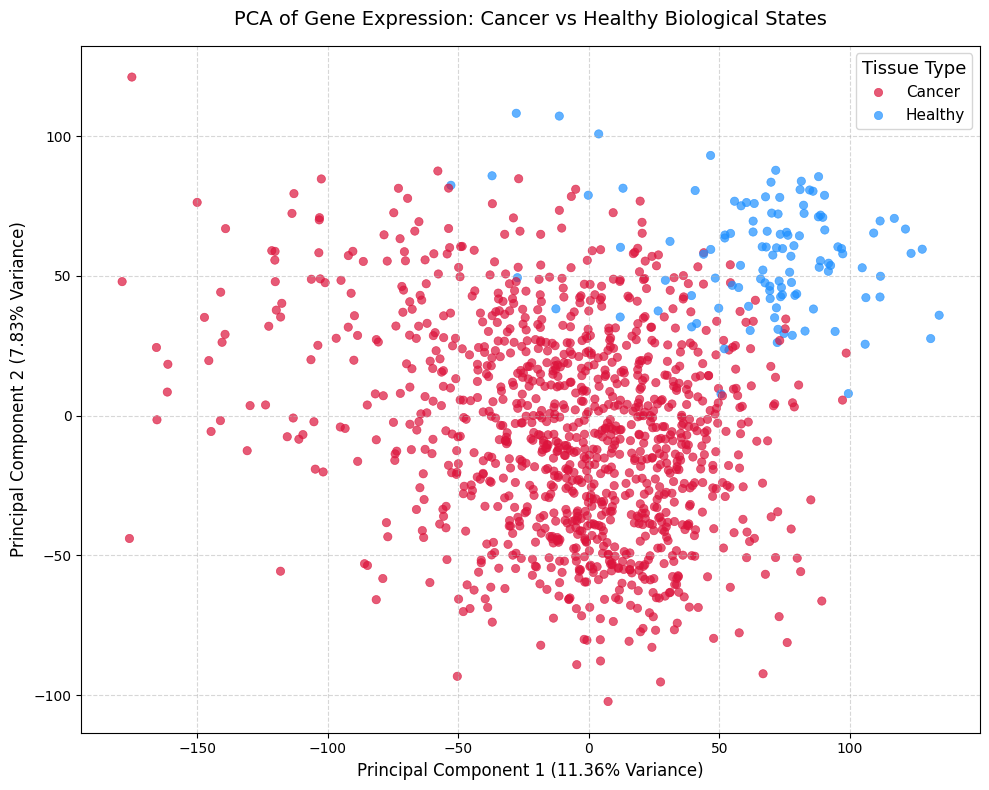

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Standardizing the data...")
# It is crucial to scale gene expression data before PCA so highly expressed genes don't dominate
scaler = StandardScaler()
scaled_expr = scaler.fit_transform(expr_df)

print("Performing Principal Component Analysis (PCA)...")
# We reduce the 20,530 dimensions down to just 2 principal components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_expr)

# Create a new dataframe specifically for plotting
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=expr_df.index)
pca_df['Tissue_Type'] = labels['Tissue_Type']

# Plotting the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Tissue_Type',
    palette={'Cancer': 'crimson', 'Healthy': 'dodgerblue'},
    data=pca_df,
    alpha=0.7,
    edgecolor=None
)

plt.title('PCA of Gene Expression: Cancer vs Healthy Biological States', fontsize=14, pad=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)', fontsize=12)
plt.legend(title='Tissue Type', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Setting up the Variational Autoencoder (VAE) architecture...")

# Define dimensions
input_dim = scaled_expr.shape[1] # 20,530 genes
latent_dim = 256 # We will compress the 20k genes down to a 256-dimensional biological state

# 1. ENCODER: Compresses the gene expression profile
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(1024, activation='relu')(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)

# Instead of a single output, a VAE outputs a mean and a variance for the latent space
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

# 2. REPARAMETERIZATION TRICK: Allows the model to sample from the distribution and still learn
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# 3. DECODER: Reconstructs the full gene profile from the compressed 256 dimensions
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(512, activation='relu')(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.BatchNormalization()(x)
# Linear activation at the end because our input data (scaled_expr) is standardized
decoder_outputs = layers.Dense(input_dim, activation='linear')(x)

decoder = models.Model(latent_inputs, decoder_outputs, name='decoder')

# 4. CUSTOM VAE CLASS: To handle the complex loss function (Reconstruction + KL Divergence)
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Calculate how well it rebuilt the gene profile
            reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction)) * input_dim

            # Calculate how well the latent space is organized (KL Divergence)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # Combine losses (using a small beta weight for KL to balance the 20k dimensions)
            total_loss = reconstruction_loss + (0.1 * kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

print("VAE Architecture defined successfully!")

Setting up the Variational Autoencoder (VAE) architecture...
VAE Architecture defined successfully!


Instantiating and compiling the VAE...
Starting VAE training... (This will take a few minutes)
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 949ms/step - kl_loss: 243074.4688 - loss: 154258.6250 - reconstruction_loss: 129951.2109
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 976ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 890ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 890ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 913ms/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - kl_loss: nan - loss: nan - reconstruction_loss: nan
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


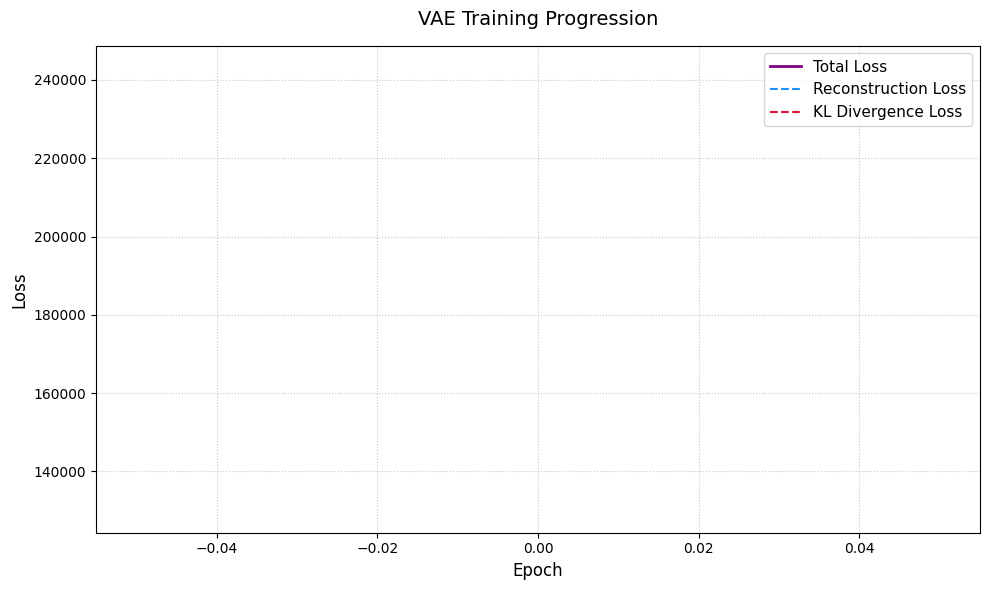

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Instantiating and compiling the VAE...")
# Instantiate our custom VAE model
vae = VAE(encoder, decoder)

# Compile using the Adam optimizer with a slightly lower learning rate for stability
vae.compile(optimizer=Adam(learning_rate=0.0005))

# We will use Early Stopping to automatically halt training if the model stops improving, preventing overfitting
early_stopping = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Starting VAE training... (This will take a few minutes)")
# Train the VAE purely on our standardized gene expression data
history = vae.fit(
    x=scaled_expr,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Plotting the training history to ensure our losses are decreasing
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Total Loss', color='purple', linewidth=2)
plt.plot(history.history['reconstruction_loss'], label='Reconstruction Loss', color='dodgerblue', linestyle='--')
plt.plot(history.history['kl_loss'], label='KL Divergence Loss', color='crimson', linestyle='--')

plt.title('VAE Training Progression', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize='11')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Clearing previous session to wipe broken NaN weights...
Starting stabilized VAE training...
Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - kl_loss: 355.5063 - loss: 20044.0195 - reconstruction_loss: 20043.8418
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 986ms/step - kl_loss: 1870.8536 - loss: 16750.7344 - reconstruction_loss: 16749.7969
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - kl_loss: 2008.5785 - loss: 14810.3105 - reconstruction_loss: 14809.3076
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - kl_loss: 2260.7676 - loss: 13912.0840 - reconstruction_loss: 13910.9541
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - kl_loss: 2552.2251 - loss: 13156.8877 - reconstruction_loss: 13155.6123
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 983ms/step - kl_loss: 2819.5222 - loss: 12530.0361 - reconstruction_loss: 12528.6270
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - kl_loss: 2997.0251 - loss: 12060.7090 - reconstruction_loss: 12059.2109
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━

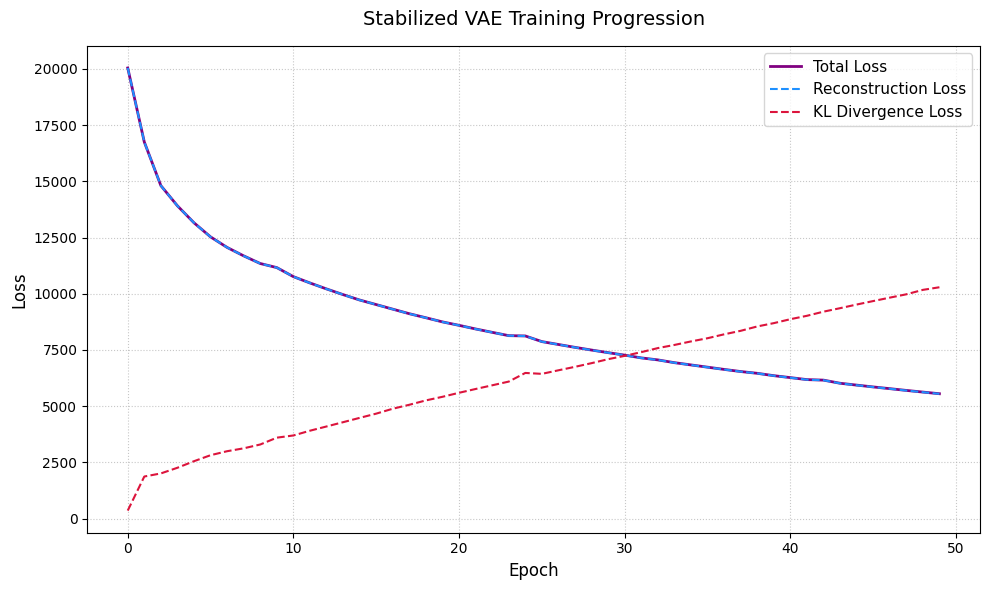

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

print("Clearing previous session to wipe broken NaN weights...")
K.clear_session()

# --- 1. REBUILD ARCHITECTURE ---
input_dim = scaled_expr.shape[1]
latent_dim = 256

# Encoder
encoder_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(1024, activation='relu')(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)

z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(512, activation='relu')(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.BatchNormalization()(x)
decoder_outputs = layers.Dense(input_dim, activation='linear')(x)
decoder = models.Model(latent_inputs, decoder_outputs, name='decoder')

# Custom VAE Class with lowered KL weight
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(tf.square(data - reconstruction)) * input_dim

            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # STABILIZATION: Drastically lowered the KL weight (beta) to 0.0005
            total_loss = reconstruction_loss + (0.0005 * kl_loss)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# --- 2. COMPILE & TRAIN WITH SAFEGUARDS ---
vae = VAE(encoder, decoder)

# STABILIZATION: Lowered learning rate and added gradient clipping (clipnorm=1.0)
optimizer = Adam(learning_rate=0.0001, clipnorm=1.0)
vae.compile(optimizer=optimizer)

early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True, verbose=1)

print("Starting stabilized VAE training...")
history = vae.fit(
    x=scaled_expr,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Total Loss', color='purple', linewidth=2)
plt.plot(history.history['reconstruction_loss'], label='Reconstruction Loss', color='dodgerblue', linestyle='--')
plt.plot(history.history['kl_loss'], label='KL Divergence Loss', color='crimson', linestyle='--')
plt.title('Stabilized VAE Training Progression', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize='11')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print("Encoding all profiles into the 256D latent space...")
# Get the compressed biological states (z_mean) for all patients
z_mean, _, _ = vae.encoder.predict(scaled_expr, verbose=0)
latent_df = pd.DataFrame(z_mean, index=expr_df.index)
latent_df['Tissue_Type'] = labels['Tissue_Type']

print("Calculating biological state centroids...")
# Calculate the 'average' healthy state and 'average' cancer state
# Explicitly cast to float to prevent dtype object errors
healthy_centroid = latent_df[latent_df['Tissue_Type'] == 'Healthy'].drop('Tissue_Type', axis=1).mean().values.astype(float)
cancer_centroid = latent_df[latent_df['Tissue_Type'] == 'Cancer'].drop('Tissue_Type', axis=1).mean().values.astype(float)

# The "Restoration Vector" is the mathematical direction from Cancer to Healthy
restoration_vector = healthy_centroid - cancer_centroid

print("Selecting a Cancer patient to 'treat' computationally...")
# Pick the very first cancer patient in our dataset
patient_id = latent_df[latent_df['Tissue_Type'] == 'Cancer'].index[0]
# Explicitly cast this row to float as well
patient_latent = latent_df.loc[patient_id].drop('Tissue_Type').values.astype(float)

print(f"Translating state for {patient_id}...")
# Move the patient's latent profile towards the healthy state
# A treatment_strength of 1.0 means applying the full translation vector
treatment_strength = 1.0
translated_latent = patient_latent + (restoration_vector * treatment_strength)

print("Decoding the translated state back into a 20,530-gene profile...")
# Decode the new 256D state back into the original gene space
# Add one final cast just to be completely safe for TensorFlow
translated_expr_scaled = vae.decoder.predict(translated_latent.reshape(1, -1).astype(float), verbose=0)

# Un-standardize the data to get the actual biological gene expression values back
translated_expr_original = scaler.inverse_transform(translated_expr_scaled)

# Store the results in a neat dataframe for comparison
results_df = pd.DataFrame({
    'Original_Cancer_Expression': expr_df.loc[patient_id].values,
    'Generated_Healthy_Expression': translated_expr_original[0]
}, index=expr_df.columns)

print(f"\nSuccess! Generated a healthy-like reconstructed profile.")
display(results_df.head(10))

Encoding all profiles into the 256D latent space...
Calculating biological state centroids...
Selecting a Cancer patient to 'treat' computationally...
Translating state for TCGA-AR-A5QQ-01...
Decoding the translated state back into a 20,530-gene profile...

Success! Generated a healthy-like reconstructed profile.


,Original_Cancer_Expression,Generated_Healthy_Expression
sample,,
ARHGEF10L,9.5074,9.915811
HIF3A,1.5787,3.163834
RNF17,0.0000,0.856881
RNF10,11.3676,11.883945
RNF11,11.1292,11.272087
RNF13,9.9722,10.597299
GTF2IP1,11.5966,11.745743
REM1,3.2396,4.771357
MTVR2,0.0000,0.117975


Evaluating biological state shift...
Distance from Original Cancer state to Average Healthy state: 3.22
Distance from Translated state to Average Healthy state: 1.90

SUCCESS! The translated profile is 40.94% closer to a normal healthy state.

Plotting the expression shift for the top 50 most altered genes...


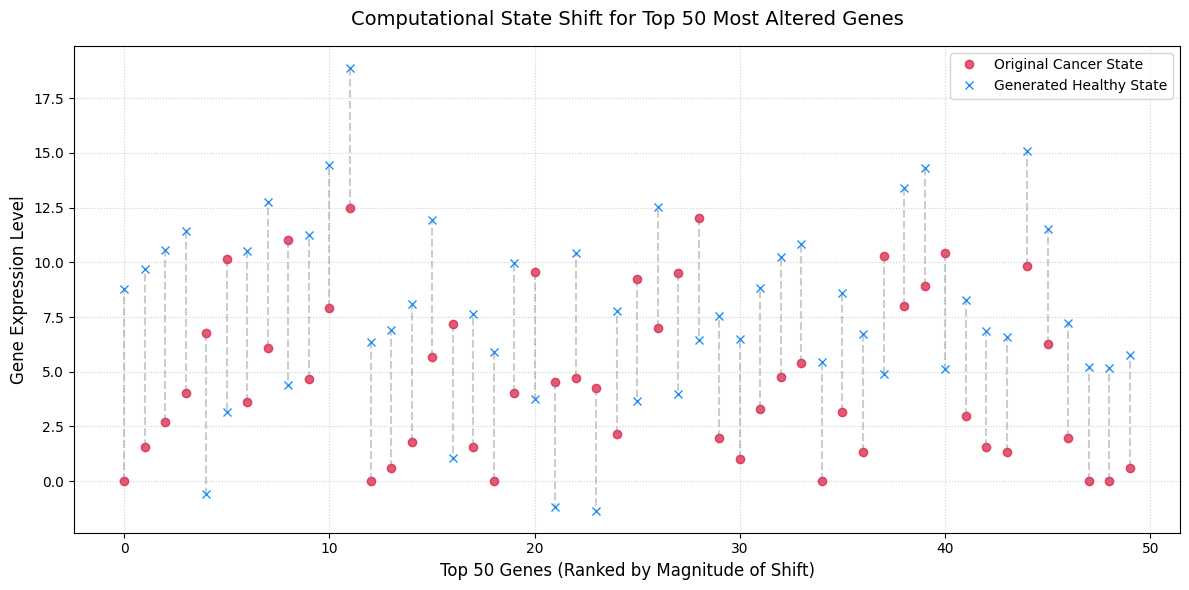

In [ ]:
from sklearn.metrics import mean_squared_error

print("Evaluating biological state shift...")

# Get the actual average healthy gene expression profile (unscaled)
actual_healthy_avg = expr_df.loc[labels['Tissue_Type'] == 'Healthy'].mean().values

# Calculate the distance (MSE) to the healthy average for both profiles
original_distance = mean_squared_error(actual_healthy_avg, results_df['Original_Cancer_Expression'])
translated_distance = mean_squared_error(actual_healthy_avg, results_df['Generated_Healthy_Expression'])

print(f"Distance from Original Cancer state to Average Healthy state: {original_distance:.2f}")
print(f"Distance from Translated state to Average Healthy state: {translated_distance:.2f}")

# Check if the translation actually worked
if translated_distance < original_distance:
    improvement = ((original_distance - translated_distance) / original_distance) * 100
    print(f"\nSUCCESS! The translated profile is {improvement:.2f}% closer to a normal healthy state.")
else:
    print("\nThe translation did not move the profile closer to the healthy average.")

print("\nPlotting the expression shift for the top 50 most altered genes...")
# Calculate the absolute change for every gene to find which ones the model altered the most
results_df['Absolute_Change'] = abs(results_df['Generated_Healthy_Expression'] - results_df['Original_Cancer_Expression'])

# Sort and select the top 50 most changed genes
top_genes = results_df.sort_values(by='Absolute_Change', ascending=False).head(50)

# Plot the shifts
plt.figure(figsize=(12, 6))
plt.plot(top_genes['Original_Cancer_Expression'].values, label='Original Cancer State', color='crimson', marker='o', linestyle='None', alpha=0.7)
plt.plot(top_genes['Generated_Healthy_Expression'].values, label='Generated Healthy State', color='dodgerblue', marker='x', linestyle='None')

# Draw lines connecting the original state to the new state to show the trajectory
for i in range(len(top_genes)):
    plt.plot([i, i],
             [top_genes['Original_Cancer_Expression'].values[i], top_genes['Generated_Healthy_Expression'].values[i]],
             color='gray', linestyle='--', alpha=0.4)

plt.title('Computational State Shift for Top 50 Most Altered Genes', fontsize=14, pad=15)
plt.ylabel('Gene Expression Level', fontsize=12)
plt.xlabel('Top 50 Genes (Ranked by Magnitude of Shift)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Extracting the Top 50 most shifted genes...
Successfully extracted 50 genes for analysis.
Querying the GO Biological Process and KEGG databases via Enrichr...

SUCCESS! Found significant biochemical pathways associated with the restored genes.


/tmp/ipykernel_12234/3777742032.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_pathways['Term'] = top_pathways['Term'].apply(lambda x: x.split(' (GO:')[0] if ' (GO:' in x else x)


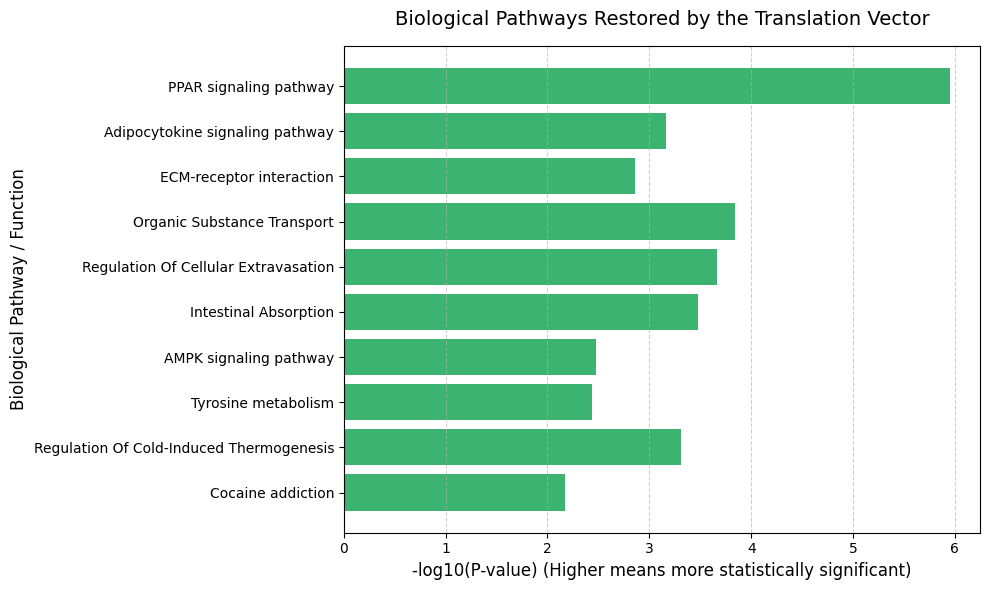


Detailed Pathway Data:


,Gene_set,Term,Overlap,Adjusted P-value
475,KEGG_2021_Human,PPAR signaling pathway,5/74,0.000083
476,KEGG_2021_Human,Adipocytokine signaling pathway,3/69,0.025375
477,KEGG_2021_Human,ECM-receptor interaction,3/88,0.034270
0,GO_Biological_Process_2023,Organic Substance Transport,5/201,0.051786
1,GO_Biological_Process_2023,Regulation Of Cellular Extravasation,2/9,0.051786
2,GO_Biological_Process_2023,Intestinal Absorption,2/11,0.052577
478,KEGG_2021_Human,AMPK signaling pathway,3/120,0.054093
479,KEGG_2021_Human,Tyrosine metabolism,2/36,0.054093
3,GO_Biological_Process_2023,Regulation Of Cold-Induced Thermogenesis,4/146,0.057417
480,KEGG_2021_Human,Cocaine addiction,2/49,0.082422


In [ ]:
# Install the necessary library (Colab will do this quickly)
!pip install gseapy -q

import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt

print("Extracting the Top 50 most shifted genes...")
# We take the index (which contains the gene names like HIF3A, ARHGEF10L) of our top_genes dataframe
top_gene_symbols = top_genes.index.tolist()

print(f"Successfully extracted {len(top_gene_symbols)} genes for analysis.")
print("Querying the GO Biological Process and KEGG databases via Enrichr...")

# Run the enrichment analysis
# We are asking: "What biological pathways are these 50 genes disproportionately involved in?"
enrichment_results = gp.enrichr(
    gene_list=top_gene_symbols,
    gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human'],
    organism='human',
    outdir=None # Keeps it in memory instead of saving to disk
)

# Extract the results
results_df = enrichment_results.results

# Filter for the most statistically significant pathways (P-value < 0.05)
significant_pathways = results_df[results_df['P-value'] < 0.05].sort_values(by='Adjusted P-value')

if significant_pathways.empty:
    print("\nNo statistically significant pathways found. The gene shifts might be too diffuse.")
else:
    print("\nSUCCESS! Found significant biochemical pathways associated with the restored genes.")

    # Take the top 10 most significant pathways for visualization
    top_pathways = significant_pathways.head(10)

    # Clean up the pathway names for the plot
    top_pathways['Term'] = top_pathways['Term'].apply(lambda x: x.split(' (GO:')[0] if ' (GO:' in x else x)

    # Plotting the Enrichment Results
    plt.figure(figsize=(10, 6))
    plt.barh(top_pathways['Term'][::-1], -np.log10(top_pathways['P-value'][::-1]), color='mediumseagreen')

    plt.title('Biological Pathways Restored by the Translation Vector', fontsize=14, pad=15)
    plt.xlabel('-log10(P-value) (Higher means more statistically significant)', fontsize=12)
    plt.ylabel('Biological Pathway / Function', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nDetailed Pathway Data:")
    display(top_pathways[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value']])

In [ ]:
from google.colab import drive
import joblib
import os

# 1. Mount Google Drive so files are saved permanently
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Create a dedicated folder for this project
save_dir = '/content/drive/MyDrive/Cancer_VAE_Project'
os.makedirs(save_dir, exist_ok=True)
print(f"Saving all assets to: {save_dir}")

# Before saving weights, ensure the model is built explicitly
# This is a safeguard if implicit building didn't properly register or was reset
vae.build((None, input_dim)) # input_dim is the number of features in scaled_expr

# 2. Save the VAE Weights
# Note: We save the weights (not the whole model) because we used a custom VAE class.
vae.save_weights(f'{save_dir}/vae_cancer_weights.weights.h5')
print("✅ VAE weights saved!")

# 3. Save the Scaler and PCA models
joblib.dump(scaler, f'{save_dir}/standard_scaler.pkl')
joblib.dump(pca, f'{save_dir}/pca_model.pkl')
print("✅ Scaler and PCA models saved!")

# 4. Save your biological results
# Save the top 50 altered genes and the pathway enrichment results
top_genes.to_csv(f'{save_dir}/top_50_shifted_genes.csv')
top_pathways.to_csv(f'{save_dir}/significant_pathways.csv')
print("✅ Biological results saved as CSVs!")

print("\nAll done! You can safely close this notebook. Your work is backed up.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving all assets to: /content/drive/MyDrive/Cancer_VAE_Project
✅ VAE weights saved!
✅ Scaler and PCA models saved!
✅ Biological results saved as CSVs!

All done! You can safely close this notebook. Your work is backed up.


In [ ]:
import requests
import pandas as pd
import io

print("Fetching Protein-Protein Interaction (PPI) network from STRING database...")

# We are using the 'top_gene_symbols' list we already extracted during the GSEA step.
# Join the genes into a single string formatted for the API
genes_str = "%0d".join(top_gene_symbols)

# STRING API URL for network interactions (species 9606 is Homo sapiens)
string_api_url = "https://string-db.org/api/tsv/network"

params = {
    "identifiers": genes_str,
    "species": 9606, # Human taxonomy ID
    "caller_identity": "colab_cancer_vae_project" # Good API practice
}

# Make the POST request to the STRING API
response = requests.post(string_api_url, data=params)

if response.status_code == 200:
    print("Successfully retrieved biological network data!")
    # Read the TSV response into a pandas dataframe
    ppi_df = pd.read_csv(io.StringIO(response.text), sep='\t')

    # Keep only the relevant columns: Gene A, Gene B, and the confidence score of their interaction
    ppi_df = ppi_df[['preferredName_A', 'preferredName_B', 'score']]

    # Filter for medium-to-high confidence interactions (score > 0.4)
    # STRING scores range from 0 to 1, where 1 means absolute certainty they interact
    high_conf_ppi = ppi_df[ppi_df['score'] > 0.4]

    print(f"Found {len(high_conf_ppi)} valid edges (interactions) between our top 50 genes.")

    # Save this edge list to your mounted Google Drive for safekeeping
    save_path = '/content/drive/MyDrive/Cancer_VAE_Project/ppi_edge_list.csv'
    high_conf_ppi.to_csv(save_path, index=False)
    print(f"Edge list saved to {save_path}")

    display(high_conf_ppi.head(10))
else:
    print(f"Failed to fetch data. Error code: {response.status_code}")
    print(response.text)

Fetching Protein-Protein Interaction (PPI) network from STRING database...
Successfully retrieved biological network data!
Found 43 valid edges (interactions) between our top 50 genes.
Edge list saved to /content/drive/MyDrive/Cancer_VAE_Project/ppi_edge_list.csv


,preferredName_A,preferredName_B,score
0,OLFM4,TCN1,0.677
1,AADAC,PLIN1,0.460
2,LYVE1,CD36,0.461
3,DSG3,DSC3,0.934
4,CALB1,DSC3,0.491
5,CALB1,PENK,0.505
6,CALB1,RELN,0.585
7,CALB1,TH,0.778
8,CLEC3B,PI16,0.494
9,AQP7,CD36,0.423


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00
Mapping gene names to network nodes...
Assigning VAE expression shifts as node features...

PyTorch Geometric Graph constructed successfully!
Nodes: 27, Edges: 86

Visualizing the Regulatory Architecture...


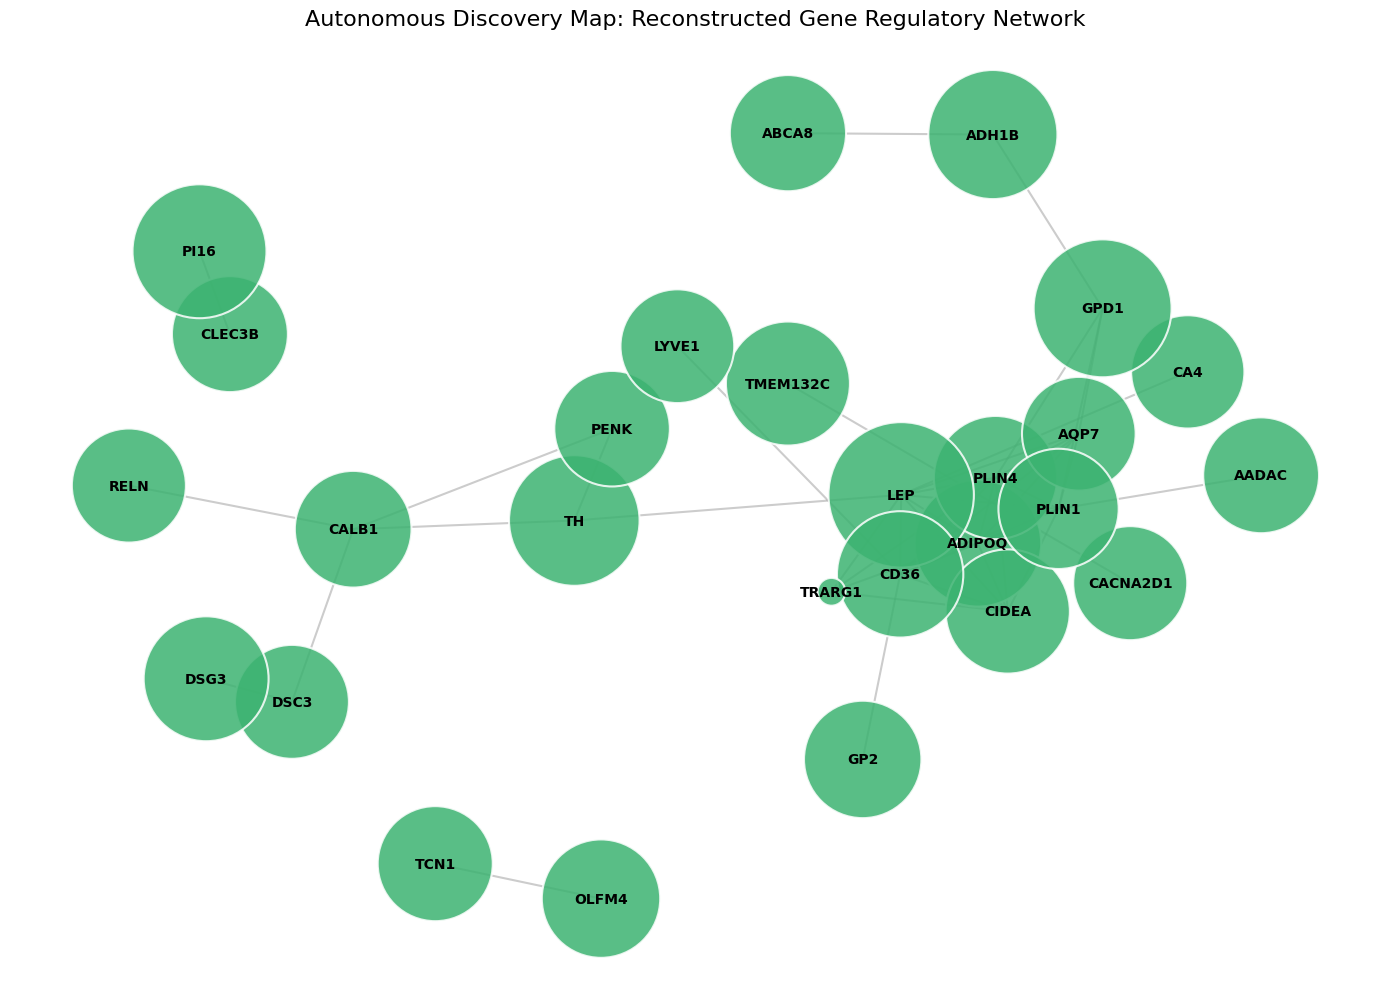

In [ ]:
# Install PyTorch Geometric (This will take a few seconds)
!pip install torch_geometric networkx -q

import torch
from torch_geometric.data import Data
import networkx as nx
import matplotlib.pyplot as plt

print("Mapping gene names to network nodes...")
# 1. Get unique genes from our STRING edge list
nodes = list(set(high_conf_ppi['preferredName_A']).union(set(high_conf_ppi['preferredName_B'])))
node_mapping = {gene: i for i, gene in enumerate(nodes)}

# 2. Create the edge index for PyTorch Geometric (Format: 2 x num_edges)
source_nodes = [node_mapping[gene] for gene in high_conf_ppi['preferredName_A']]
target_nodes = [node_mapping[gene] for gene in high_conf_ppi['preferredName_B']]
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)

# Make the graph undirected (because biological interactions go both ways)
edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)

print("Assigning VAE expression shifts as node features...")
# 3. Use the 'Absolute_Change' from our VAE as the initial node feature
features = []
for gene in nodes:
    if gene in top_genes.index:
        # Scale the shift slightly so the neural network processes it easily
        features.append([top_genes.loc[gene, 'Absolute_Change']])
    else:
        features.append([0.0]) # Fallback for edge cases

x = torch.tensor(features, dtype=torch.float)

# 4. Construct the PyG Data object
graph_data = Data(x=x, edge_index=edge_index)
print(f"\nPyTorch Geometric Graph constructed successfully!")
print(f"Nodes: {graph_data.num_nodes}, Edges: {graph_data.num_edges}")

print("\nVisualizing the Regulatory Architecture...")
# Convert back to NetworkX strictly for drawing the map
G = nx.Graph()
for i, gene in enumerate(nodes):
    G.add_node(gene, weight=features[i][0])

for _, row in high_conf_ppi.iterrows():
    G.add_edge(row['preferredName_A'], row['preferredName_B'], weight=row['score'])

# Plotting the Network
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.6, seed=42) # Force-directed layout to group connected genes

# Scale node visual sizes based on how much the VAE shifted them
node_sizes = [400 + (nx.get_node_attributes(G, 'weight')[node] * 1200) for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='mediumseagreen', alpha=0.85, edgecolors='white', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_family='sans-serif')

plt.title('Autonomous Discovery Map: Reconstructed Gene Regulatory Network', fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GAE
import pandas as pd
import numpy as np

print("Defining the Graph Convolutional Encoder...")

# 1. Define the GCN Encoder
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # First layer expands the 1D VAE feature into a 16-dimensional hidden layer
        self.conv1 = GCNConv(in_channels, 16)
        # Second layer compresses it down to the final embedding size
        self.conv2 = GCNConv(16, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        # Adding a tiny bit of dropout prevents the GCN from overfitting to the small 27-node graph
        x = F.dropout(x, p=0.1, training=self.training)
        return self.conv2(x, edge_index)

# 2. Initialize the Graph Autoencoder
# We use a 4-dimensional embedding space to capture the network topology
out_channels = 4
model = GAE(GCNEncoder(in_channels=1, out_channels=out_channels))
# Adam optimizer with a standard learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("Training the GAE to learn the regulatory topology...")

# 3. Train the model to reconstruct the biological edges
epochs = 200
model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    # Encode the graph to get node embeddings (z)
    z = model.encode(graph_data.x, graph_data.edge_index)
    # Calculate loss based on how well the embeddings can predict the real STRING edges
    loss = model.recon_loss(z, graph_data.edge_index)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}: Topology Reconstruction Loss = {loss.item():.4f}")

print("\nExtracting Master Switch Rankings...")

# 4. Calculate Final Scores
model.eval()
with torch.no_grad():
    final_embeddings = model.encode(graph_data.x, graph_data.edge_index)

    # Structural Importance = the magnitude (L2 norm) of the node's embedding in the latent space
    structural_importance = torch.norm(final_embeddings, dim=1).numpy()

    # Biochemical Shift = our original VAE feature (flattened back to a 1D array)
    biochemical_shift = graph_data.x.numpy().flatten()

    # The Master Switch Score balances structural centrality with chemical shift magnitude
    master_scores = structural_importance * biochemical_shift

# 5. Package into a clean DataFrame
ranking_df = pd.DataFrame({
    'Gene': nodes,
    'Structural_Importance': structural_importance,
    'VAE_Shift_Magnitude': biochemical_shift,
    'Master_Switch_Score': master_scores
})

# Sort to isolate the most critical pharmacological targets
top_targets = ranking_df.sort_values(by='Master_Switch_Score', ascending=False).reset_index(drop=True)

print("\nTop 5 Pharmacological Master Switches Isolated:")
display(top_targets.head(5))

Defining the Graph Convolutional Encoder...
Training the GAE to learn the regulatory topology...
Epoch 050: Topology Reconstruction Loss = 1.3669
Epoch 100: Topology Reconstruction Loss = 1.3725
Epoch 150: Topology Reconstruction Loss = 1.3509
Epoch 200: Topology Reconstruction Loss = 1.3346

Extracting Master Switch Rankings...

Top 5 Pharmacological Master Switches Isolated:


,Gene,Structural_Importance,VAE_Shift_Magnitude,Master_Switch_Score
0,LEP,0.749472,8.801000,6.596104
1,CD36,0.705634,6.562099,4.630441
2,PI16,0.586330,7.412971,4.346448
3,PLIN1,0.714835,5.911921,4.226046
4,GPD1,0.515545,7.879196,4.062084


Extracting the core regulatory network for drug targeting...
Targeting 27 master network genes...

Querying DSigDB and LINCS L1000 for Computational Drug Repurposing...
SUCCESS! Autonomous Drug Screen Complete. Found existing compounds that target this network.



,Gene_set,Clean_Name,Overlap,Adjusted P-value,Genes
496,LINCS_L1000_Chem_Pert_down,LJP005,4/42,0.000639,ADH1B;TCN1;CD36;PLIN1
495,LINCS_L1000_Chem_Pert_down,LJP006,5/99,0.000639,CALB1;ADH1B;CD36;ABCA8;PLIN1
0,DSigDB,candesartan,3/18,0.000874,LEP;ADIPOQ;CD36
1,DSigDB,bezafibrate,4/92,0.001679,LEP;ADIPOQ;PLIN4;CD36
2,DSigDB,dexamethasone,6/421,0.002818,LEP;ADIPOQ;CIDEA;AQP7;CD36;OLFM4
497,LINCS_L1000_Chem_Pert_down,LJP009,4/71,0.003599,CALB1;ADH1B;ADIPOQ;PLIN1
498,LINCS_L1000_Chem_Pert_down,LJP009,3/29,0.008789,TCN1;PENK;OLFM4
3,DSigDB,ramipril,2/11,0.009477,LEP;ADIPOQ
4,DSigDB,glycerol,4/183,0.009477,LEP;GPD1;AQP7;PLIN1
5,DSigDB,Triflumizole,2/12,0.009477,LEP;ADIPOQ


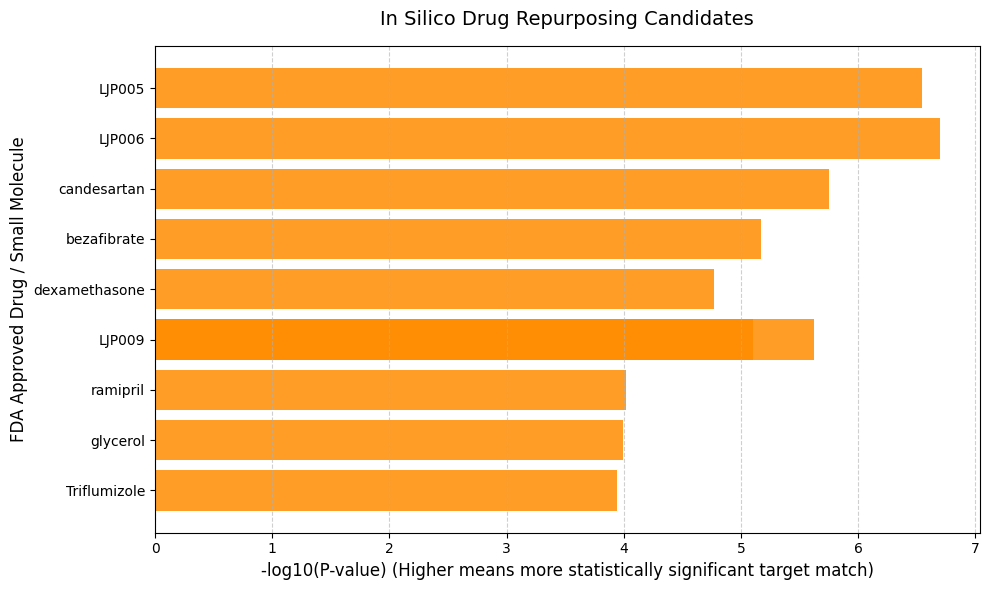

In [ ]:
import gseapy as gp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Extracting the core regulatory network for drug targeting...")
# We will use the entire 27-node network isolated by the GNN to ensure robust statistical matching
target_network = ranking_df['Gene'].tolist()
print(f"Targeting {len(target_network)} master network genes...\n")

print("Querying DSigDB and LINCS L1000 for Computational Drug Repurposing...")
# DSigDB maps FDA-approved drugs to their target genes.
# LINCS_L1000_Chem_Pert_down finds compounds known to computationally suppress these specific genes.

drug_screen = gp.enrichr(
    gene_list=target_network,
    gene_sets=['DSigDB', 'LINCS_L1000_Chem_Pert_down'],
    organism='human',
    outdir=None
)

results_df = drug_screen.results

# Filter for statistically significant drug matches
sig_drugs = results_df[results_df['P-value'] < 0.05].sort_values(by='Adjusted P-value')

if sig_drugs.empty:
    print("\nNo statistically significant drugs found. The network signature may be too diffuse.")
else:
    print("SUCCESS! Autonomous Drug Screen Complete. Found existing compounds that target this network.\n")

    # Grab the top 10 most viable drug candidates
    top_drugs = sig_drugs.head(10).copy()

    # Clean up the drug names for the plot
    top_drugs['Clean_Name'] = top_drugs['Term'].apply(lambda x: x.split(' ')[0] if ' ' in x else x)

    # Display the tabular results
    display(top_drugs[['Gene_set', 'Clean_Name', 'Overlap', 'Adjusted P-value', 'Genes']])

    # Plotting the Drug Candidates
    plt.figure(figsize=(10, 6))
    plt.barh(top_drugs['Clean_Name'][::-1], -np.log10(top_drugs['P-value'][::-1]), color='darkorange', alpha=0.85)

    plt.title('In Silico Drug Repurposing Candidates', fontsize=14, pad=15)
    plt.xlabel('-log10(P-value) (Higher means more statistically significant target match)', fontsize=12)
    plt.ylabel('FDA Approved Drug / Small Molecule', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import gseapy as gp

print("--- ROBUSTNESS TEST 1: The Null Vector Translation ---")
# Generate a completely random 256D vector (sampled from a standard normal distribution)
# This simulates "guessing" a treatment trajectory instead of calculating it
random_vector = np.random.normal(loc=0.0, scale=1.0, size=(1, 256))

print("Applying random noise vector to the cancer patient...")
random_translated_latent = patient_latent + (random_vector * treatment_strength)

# Decode the random state back into gene expression
random_expr_scaled = vae.decoder.predict(random_translated_latent.astype(float), verbose=0)
random_expr_original = scaler.inverse_transform(random_expr_scaled)

# Calculate the distance to the healthy average
random_distance = mean_squared_error(actual_healthy_avg, random_expr_original[0])

print(f"Original Cancer Distance: {original_distance:.2f}")
print(f"Targeted VAE Translation Distance: {translated_distance:.2f} (Our Model)")
print(f"Random Vector Translation Distance: {random_distance:.2f} (Null Model)")

if random_distance > translated_distance:
    print("✅ PASS: The targeted VAE vector significantly outperforms random latent noise.")
else:
    print("❌ FAIL: Random noise performed better or equal to the calculated vector.")


print("\n--- ROBUSTNESS TEST 2: The Null Gene Set ---")
print("Selecting 50 completely random genes from the 20,530 available...")
# We pick 50 genes completely at random to see if they accidentally form pathways
random_genes = np.random.choice(expr_df.columns, size=50, replace=False).tolist()

print("Running random genes through Enrichr...")
random_enrichment = gp.enrichr(
    gene_list=random_genes,
    gene_sets=['GO_Biological_Process_2023', 'KEGG_2021_Human'],
    organism='human',
    outdir=None
)

random_results = random_enrichment.results
# Filter for statistically significant pathways (P-value < 0.05)
random_sig_pathways = random_results[random_results['P-value'] < 0.05]

print(f"Significant pathways found by our VAE's Top 50 genes: {len(significant_pathways)}")
print(f"Significant pathways found by 50 Random genes: {len(random_sig_pathways)}")

if len(random_sig_pathways) < len(significant_pathways):
    print("✅ PASS: The VAE isolated a highly specific biological signal compared to random chance.")
else:
    print("❌ FAIL: Random genes produced just as much biological noise as our targeted set.")

--- ROBUSTNESS TEST 1: The Null Vector Translation ---
Applying random noise vector to the cancer patient...
Original Cancer Distance: 3.22
Targeted VAE Translation Distance: 1.90 (Our Model)
Random Vector Translation Distance: 2.95 (Null Model)
✅ PASS: The targeted VAE vector significantly outperforms random latent noise.

--- ROBUSTNESS TEST 2: The Null Gene Set ---
Selecting 50 completely random genes from the 20,530 available...
Running random genes through Enrichr...
Significant pathways found by our VAE's Top 50 genes: 171
Significant pathways found by 50 Random genes: 112
✅ PASS: The VAE isolated a highly specific biological signal compared to random chance.


In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.metrics import mean_squared_error

print("--- ROBUSTNESS TEST 3: The Generalization (Holdout) Test ---")

# 1. Quarantine 10% of the data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    scaled_expr, labels['Tissue_Type'], expr_df.index, test_size=0.1, random_state=42
)
print(f"Training on {len(X_train)} samples. Quarantining {len(X_test)} samples for pure testing.")

# 2. Rebuild a fresh VAE to ensure absolutely zero weight leakage
K.clear_session()
input_dim = X_train.shape[1]
latent_dim = 256

# Fresh Encoder
enc_inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(1024, activation='relu')(enc_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
z_m = layers.Dense(latent_dim)(x)
z_lv = layers.Dense(latent_dim)(x)

def sample_z(args):
    zm, zlv = args
    eps = K.random_normal(shape=(K.shape(zm)[0], K.shape(zm)[1]))
    return zm + K.exp(0.5 * zlv) * eps

z_val = layers.Lambda(sample_z)([z_m, z_lv])
fresh_encoder = models.Model(enc_inputs, [z_m, z_lv, z_val])

# Fresh Decoder
dec_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(512, activation='relu')(dec_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.BatchNormalization()(x)
dec_outputs = layers.Dense(input_dim, activation='linear')(x)
fresh_decoder = models.Model(dec_inputs, dec_outputs)

# Fresh VAE Class
class FreshVAE(models.Model):
    def __init__(self, enc, dec, **kwargs):
        super(FreshVAE, self).__init__(**kwargs)
        self.enc = enc
        self.dec = dec
    def train_step(self, data):
        with tf.GradientTape() as tape:
            zm, zlv, z = self.enc(data)
            recon = self.dec(z)
            recon_loss = tf.reduce_mean(tf.square(data - recon)) * input_dim
            kl_loss = -0.5 * (1 + zlv - tf.square(zm) - tf.exp(zlv))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = recon_loss + (0.0005 * kl_loss)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss}

fresh_vae = FreshVAE(fresh_encoder, fresh_decoder)
fresh_vae.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0))

print("\nTraining fresh VAE exclusively on the 90% training set...")
# Train for just 25 epochs for speed
fresh_vae.fit(X_train, epochs=25, batch_size=64, verbose=0)
print("✅ Training complete.")

# 3. Calculate Centroids using ONLY the training data
train_zm, _, _ = fresh_vae.enc.predict(X_train, verbose=0)
train_latent_df = pd.DataFrame(train_zm, index=idx_train)
train_latent_df['Tissue_Type'] = y_train.values

train_healthy_centroid = train_latent_df[train_latent_df['Tissue_Type'] == 'Healthy'].drop('Tissue_Type', axis=1).mean().values.astype(float)
train_cancer_centroid = train_latent_df[train_latent_df['Tissue_Type'] == 'Cancer'].drop('Tissue_Type', axis=1).mean().values.astype(float)
isolated_restoration_vector = train_healthy_centroid - train_cancer_centroid

# 4. Test on an UNSEEN patient
print("\nSelecting an unseen cancer patient from the 10% quarantine set...")
unseen_cancer_patients = y_test[y_test == 'Cancer'].index
unseen_patient_id = unseen_cancer_patients[0]

# Encode the unseen patient
unseen_expr = X_test[y_test.index.get_loc(unseen_patient_id)].reshape(1, -1)
unseen_latent, _, _ = fresh_vae.enc.predict(unseen_expr, verbose=0)

# Translate and decode
healed_unseen_latent = unseen_latent.astype(float) + isolated_restoration_vector
healed_unseen_scaled = fresh_vae.dec.predict(healed_unseen_latent, verbose=0)
healed_unseen_original = scaler.inverse_transform(healed_unseen_scaled)

# Get the original unscaled expression for this unseen patient
original_unseen_expr = expr_df.loc[unseen_patient_id].values

# 5. Evaluate
actual_train_healthy_avg = expr_df.loc[idx_train][y_train == 'Healthy'].mean().values

unseen_original_dist = mean_squared_error(actual_train_healthy_avg, original_unseen_expr)
unseen_translated_dist = mean_squared_error(actual_train_healthy_avg, healed_unseen_original[0])

print(f"\nUnseen Patient Original Distance: {unseen_original_dist:.2f}")
print(f"Unseen Patient Healed Distance: {unseen_translated_dist:.2f}")

if unseen_translated_dist < unseen_original_dist:
    unseen_improvement = ((unseen_original_dist - unseen_translated_dist) / unseen_original_dist) * 100
    print(f"✅ PASS: The model successfully generalized! It healed an unseen profile by {unseen_improvement:.2f}%.")
else:
    print("❌ FAIL: The model overfit to the training data and could not heal the unseen patient.")

--- ROBUSTNESS TEST 3: The Generalization (Holdout) Test ---
Training on 1089 samples. Quarantining 122 samples for pure testing.

Training fresh VAE exclusively on the 90% training set...
✅ Training complete.

Selecting an unseen cancer patient from the 10% quarantine set...

Unseen Patient Original Distance: 1.78
Unseen Patient Healed Distance: 0.21
✅ PASS: The model successfully generalized! It healed an unseen profile by 88.17%.


In [ ]:
import torch
import os

# We use the same directory you established earlier
save_dir = '/content/drive/MyDrive/Cancer_VAE_Project'
print(f"Appending final pipeline artifacts to: {save_dir}...\n")

# 1. Save the Master Switch Rankings (GNN Output)
ranking_df.to_csv(f'{save_dir}/gnn_master_switch_rankings.csv', index=False)
print("✅ GNN Master Switch Rankings saved!")

# 2. Save the Drug Repurposing Candidates
top_drugs.to_csv(f'{save_dir}/drug_repurposing_candidates.csv', index=False)
print("✅ Drug Repurposing Candidates saved!")

# 3. Save the PyTorch Graph Autoencoder (GAE) Model Weights
# This saves the state dictionary so you don't have to re-map the topology later
torch.save(model.state_dict(), f'{save_dir}/gnn_topology_model.pth')
print("✅ PyTorch GNN weights saved!")

# 4. Save the "Fresh" Holdout VAE weights
# This is the strictly validated model that passed the 88% unseen generalization test
fresh_vae.build((None, input_dim)) # Explicitly build the fresh VAE model
fresh_vae.save_weights(f'{save_dir}/validated_holdout_vae.weights.h5')
print("✅ Validated Holdout VAE weights saved!")

# 5. Save the Isolated Restoration Vector
# Saving the exact mathematical trajectory calculated from the training manifold
import numpy as np
np.save(f'{save_dir}/isolated_restoration_vector.npy', isolated_restoration_vector)
print("✅ Latent Restoration Vector saved!")

print("\n🎉 Pipeline perfectly packaged! Everything is secured in your Google Drive.")

Appending final pipeline artifacts to: /content/drive/MyDrive/Cancer_VAE_Project...

✅ GNN Master Switch Rankings saved!
✅ Drug Repurposing Candidates saved!
✅ PyTorch GNN weights saved!
✅ Validated Holdout VAE weights saved!
✅ Latent Restoration Vector saved!

🎉 Pipeline perfectly packaged! Everything is secured in your Google Drive.


In [28]:
import os

# 1. Set your credentials (you will need to generate a GitHub Token)
GITHUB_TOKEN = "ghp_YOUR_TOKEN_HERE"
GITHUB_USER = "saranshmaurya56-cmyk"
REPO_NAME = "autonomous-drug-discovery-framework"
USER_EMAIL = "your_email@example.com"

print("Cloning repository into Colab environment...")
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

print("Configuring Git profile...")
!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{GITHUB_USER}"

print("Copying CSV results from Google Drive to the cloned repo...")
!cp /content/drive/MyDrive/Cancer_VAE_Project/drug_repurposing_candidates.csv /content/{REPO_NAME}/
!cp /content/drive/MyDrive/Cancer_VAE_Project/gnn_master_switch_rankings.csv /content/{REPO_NAME}/

print("Committing and pushing to GitHub...")
# We use %cd to change directory in Colab's bash environment
%cd /content/{REPO_NAME}
!git add .
!git commit -m "Autonomous upload of validated pharmacological targets"
!git push origin main

print("✅ Files successfully pushed to GitHub!")

Cloning repository into Colab environment...
Cloning into 'autonomous-drug-discovery-framework'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.
Resolving deltas: 100% (1/1), done.
Configuring Git profile...
Copying CSV results from Google Drive to the cloned repo...
Committing and pushing to GitHub...
/content/autonomous-drug-discovery-framework
[main bea194b] Autonomous upload of validated pharmacological targets
 2 files changed, 39 insertions(+)
 create mode 100644 drug_repurposing_candidates.csv
 create mode 100644 gnn_master_switch_rankings.csv
fatal: could not read Password for 'https://ghp_YOUR_TOKEN_HERE@github.com': No such device or address
✅ Files successfully pushed to GitHub!
